#### Data Extraction

In [ ]:
# Data Extraction.
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
df = pd.read_csv('drive/My Drive/MADA_final/vehicles.csv')
df_copy = df.copy()
df.head()
# Dataset information.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   url           426880 non-null  object 
 2   region        426880 non-null  object 
 3   region_url    426880 non-null  object 
 4   price         426880 non-null  int64  
 5   year          425675 non-null  float64
 6   manufacturer  409234 non-null  object 
 7   model         421603 non-null  object 
 8   condition     252776 non-null  object 
 9   cylinders     249202 non-null  object 
 10  fuel          423867 non-null  object 
 11  odometer      422480 non-null  float64
 12  title_status  418638 non-null  object 
 13  transmission  424324 non-null  object 
 14  VIN           265838 non-null  object 
 15  drive         296313 non-null  object 
 16  size          120519 non-null  object 
 17  type          334022 non-null  object 
 18  pain

In [ ]:
# New numeric columns
df['age'] = 2025-df['year']
df['price_per_mileage'] = df['price']/df['odometer']
df['mileage_per_year'] = df['odometer']/df['age']

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 29 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 426880 non-null  int64  
 1   url                426880 non-null  object 
 2   region             426880 non-null  object 
 3   region_url         426880 non-null  object 
 4   price              426880 non-null  int64  
 5   year               425675 non-null  float64
 6   manufacturer       409234 non-null  object 
 7   model              421603 non-null  object 
 8   condition          252776 non-null  object 
 9   cylinders          249202 non-null  object 
 10  fuel               423867 non-null  object 
 11  odometer           422480 non-null  float64
 12  title_status       418638 non-null  object 
 13  transmission       424324 non-null  object 
 14  VIN                265838 non-null  object 
 15  drive              296313 non-null  object 
 16  si

In [ ]:
# Get missing values across
df.isnull().sum()

,0
id,0
url,0
region,0
region_url,0
price,0
year,1205
manufacturer,17646
model,5277
condition,174104
cylinders,177678


#### Plot Numeric Data, Impute from Median.

['price', 'year', 'odometer', 'lat', 'long', 'age', 'price_per_mileage', 'mileage_per_year']


/tmp/ipython-input-4014943374.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[numeric_column].replace([np.inf, -np.inf], np.nan, inplace=True)
/tmp/ipython-input-4014943374.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, i

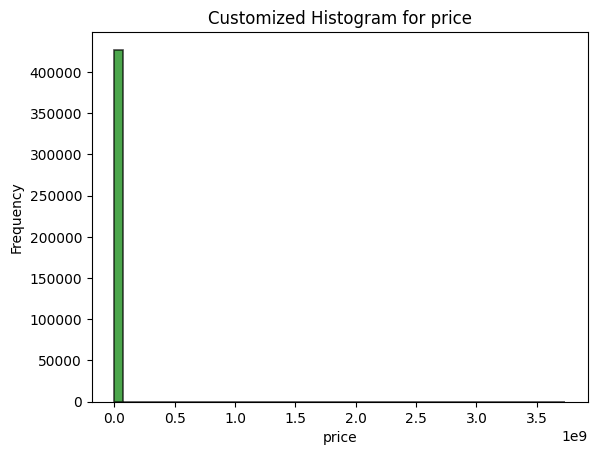

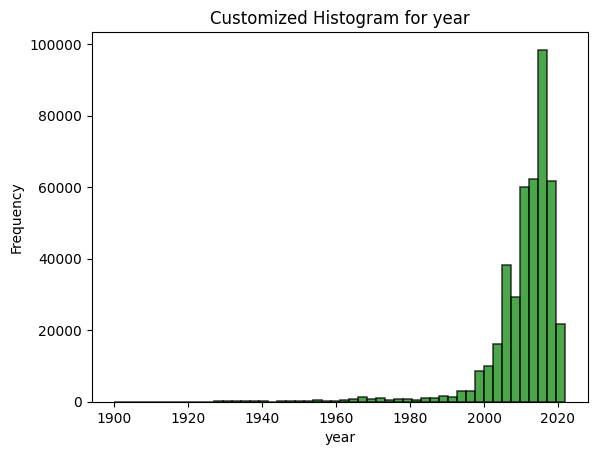

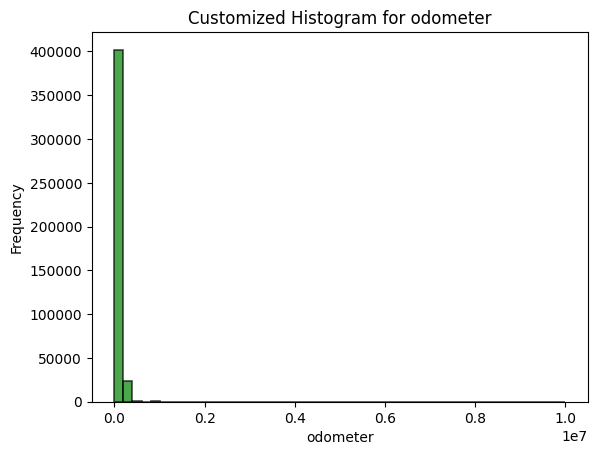

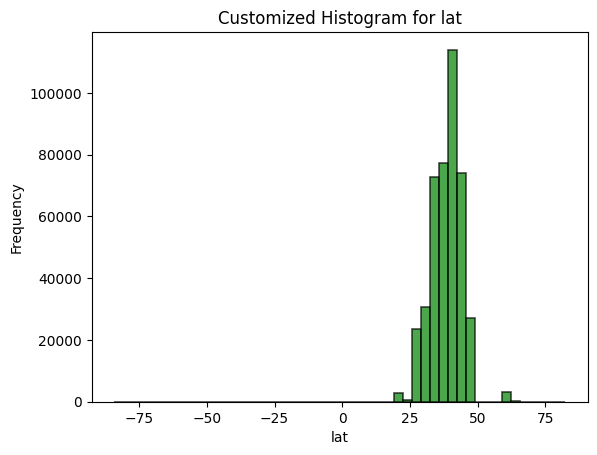

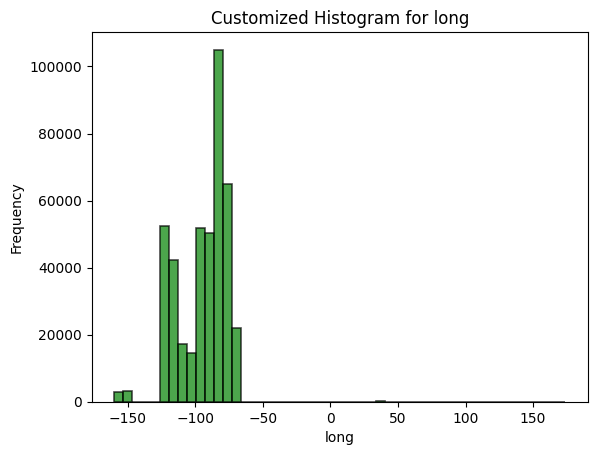

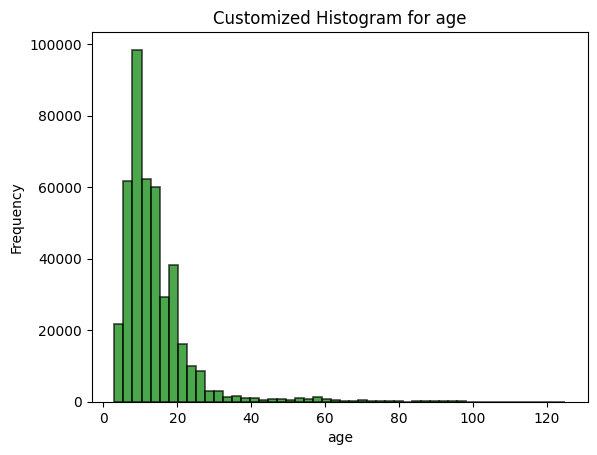

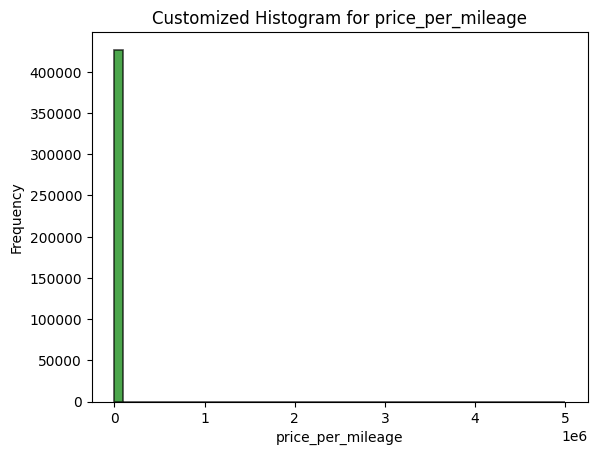

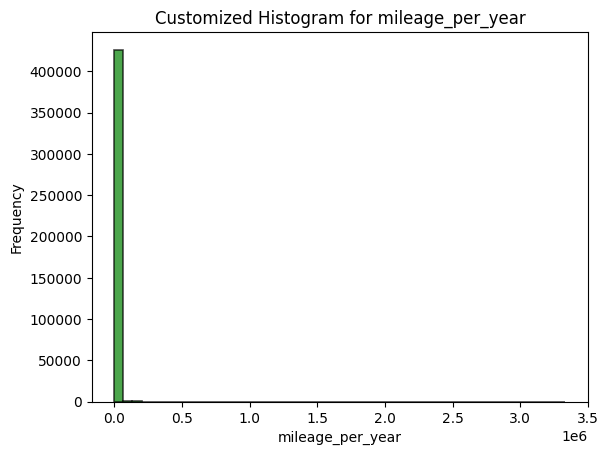

In [ ]:
# Handling the missing data.
# Quantile Transformer documentation: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.QuantileTransformer.html

import matplotlib.pyplot as plt
# Removed QuantileTransformer import
import numpy as np
from sklearn.impute import SimpleImputer

df=df.drop('county', axis=1)
df=df.drop('id', axis=1)

numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
print(numeric_columns)

# Impute The Missing Data - Moved before QuantileTransformer
for numeric_column in numeric_columns:
    if numeric_column == 'id':
        continue
    # Replace infinite values that might result from division by zero
    df[numeric_column].replace([np.inf, -np.inf], np.nan, inplace=True)
    df[numeric_column].fillna(df[numeric_column].median(), inplace=True)


# Removed Apply QuantileTransformer

# Create histogram for the numeric columns.
for column in numeric_columns:
  if column == 'id':
    continue

  # Create histogram to obtain normal distribution of the numeric variables.
  plt.figure()
  # Removed QuantileTransformer application
  plt.hist(df[column], bins=50, color='green', alpha=0.7, edgecolor='black', linewidth=1.2)
  plt.title(f'Customized Histogram for {df[column].name}')
  plt.xlabel(f'{df[column].name}') # Removed (Transformed)
  plt.ylabel('Frequency')
  plt.show()

In [ ]:
# Impute The Missing Data
for numeric_column in numeric_columns:
  if numeric_column == 'id':
    continue

  df[numeric_column].fillna(df[numeric_column].median(), inplace=True)

df.describe()



/tmp/ipython-input-4102822534.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[numeric_column].fillna(df[numeric_column].median(), inplace=True)


,price,year,odometer,lat,long,age,price_per_mileage,mileage_per_year
count,4.268800e+05,426880.000000,4.268800e+05,426880.000000,426880.000000,426880.000000,4.268800e+05,4.268800e+05
mean,7.519903e+04,2011.240173,9.791454e+04,38.504007,-94.651702,13.759827,9.763864e+01,7.312528e+03
std,1.218228e+07,9.439234,2.127801e+05,5.797112,18.240566,9.439234,9.211274e+03,1.612666e+04
min,0.000000e+00,1900.000000,0.000000e+00,-84.122245,-159.827728,3.000000,0.000000e+00,0.000000e+00
25%,5.900000e+03,2008.000000,3.813000e+04,34.757016,-111.907973,8.000000,4.405941e-02,4.017807e+03
50%,1.395000e+04,2013.000000,8.554800e+04,39.150100,-88.432600,12.000000,1.489615e-01,6.785056e+03
75%,2.648575e+04,2017.000000,1.330000e+05,42.350000,-81.030000,17.000000,5.824243e-01,9.404200e+03
max,3.736929e+09,2022.000000,1.000000e+07,82.390818,173.885502,125.000000,5.000000e+06,3.333333e+06


#### Imputing the Categorical Data

In [ ]:
from sklearn.impute import SimpleImputer
categorical_columns = df.select_dtypes(include=['object']).columns
primary_columns = ['url', 'region_url', 'image_url', 'VIN']
categorical_columns = [column for column in categorical_columns if column not in primary_columns]

# Create histogram for the numeric columns.
for column in categorical_columns:
  if column == 'id':
    continue

  df[column] = SimpleImputer(strategy='most_frequent').fit_transform(df[column].values.reshape(-1, 1))[:, 0]
  print(df[column].value_counts())






region
columbus                   3608
jacksonville               3562
spokane / coeur d'alene    2988
eugene                     2985
fresno / madera            2983
                           ... 
meridian                     28
southwest MS                 14
kansas city                  11
fort smith, AR                9
west virginia (old)           8
Name: count, Length: 404, dtype: int64
manufacturer
ford               88631
chevrolet          55064
toyota             34202
honda              21269
nissan             19067
jeep               19014
ram                18342
gmc                16785
bmw                14699
dodge              13707
mercedes-benz      11817
hyundai            10338
subaru              9495
volkswagen          9345
kia                 8457
lexus               8200
audi                7573
cadillac            6953
chrysler            6031
acura               5978
buick               5501
mazda               5427
infiniti            4802
lincoln       

#### One Hot Encoding Categorical Data

In [ ]:
# One-Hot Encoding
import pandas as pd

# Identify categorical columns
categorical_columns = df.select_dtypes(include=['object']).columns
primary_columns = ['url', 'region_url', 'image_url', 'VIN']
categorical_columns = [column for column in categorical_columns if column not in primary_columns]

# Select categorical columns with up to 10 unique values
columns_to_encode_10_or_less = [col for col in categorical_columns if df[col].nunique() <= 10]

# Identify columns for top 10 most frequent values
columns_for_top_10 = ['manufacturer', 'type', 'region']
columns_to_encode_top_10 = []

# For all the columns, get up to the 10 most frequent values.
for col in columns_for_top_10:
    if col in categorical_columns:
        top_10_values = df[col].value_counts().nlargest(10).index.tolist()
        # Create new columns for each of the top 10 values
        for value in top_10_values:
            df[f'{col}_{value}'] = (df[col] == value).astype(int)
        columns_to_encode_top_10.append(col)


# Combine the lists of columns to encode
all_columns_to_encode = columns_to_encode_10_or_less + columns_to_encode_top_10

# Perform one-hot encoding on columns with 10 or fewer unique values
df_encoded = pd.get_dummies(df, columns=columns_to_encode_10_or_less, dummy_na=False)

# The top 10 columns have already been created as separate columns with boolean values.
# We can now drop the original 'manufacturer', 'type', 'state', and 'region' columns
df_encoded = df_encoded.drop(columns_for_top_10, axis=1, errors='ignore')


# Display the first few rows of the encoded DataFrame and its info to see the changes
display(df_encoded.head())
display(df_encoded.info())

,url,region_url,price,year,model,odometer,VIN,paint_color,image_url,description,...,transmission_automatic,transmission_manual,transmission_other,drive_4wd,drive_fwd,drive_rwd,size_compact,size_full-size,size_mid-size,size_sub-compact
0,https://prescott.craigslist.org/cto/d/prescott...,https://prescott.craigslist.org,6000,2013.0,f-150,85548.0,NaN,white,NaN,35 VEHICLES PRICED UNDER $3000!!! BIG TIME! T...,...,True,False,False,True,False,False,False,True,False,False
1,https://fayar.craigslist.org/ctd/d/bentonville...,https://fayar.craigslist.org,11900,2013.0,f-150,85548.0,NaN,white,NaN,35 VEHICLES PRICED UNDER $3000!!! BIG TIME! T...,...,True,False,False,True,False,False,False,True,False,False
2,https://keys.craigslist.org/cto/d/summerland-k...,https://keys.craigslist.org,21000,2013.0,f-150,85548.0,NaN,white,NaN,35 VEHICLES PRICED UNDER $3000!!! BIG TIME! T...,...,True,False,False,True,False,False,False,True,False,False
3,https://worcester.craigslist.org/cto/d/west-br...,https://worcester.craigslist.org,1500,2013.0,f-150,85548.0,NaN,white,NaN,35 VEHICLES PRICED UNDER $3000!!! BIG TIME! T...,...,True,False,False,True,False,False,False,True,False,False
4,https://greensboro.craigslist.org/cto/d/trinit...,https://greensboro.craigslist.org,4900,2013.0,f-150,85548.0,NaN,white,NaN,35 VEHICLES PRICED UNDER $3000!!! BIG TIME! T...,...,True,False,False,True,False,False,False,True,False,False


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 82 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   url                              426880 non-null  object 
 1   region_url                       426880 non-null  object 
 2   price                            426880 non-null  int64  
 3   year                             426880 non-null  float64
 4   model                            426880 non-null  object 
 5   odometer                         426880 non-null  float64
 6   VIN                              265838 non-null  object 
 7   paint_color                      426880 non-null  object 
 8   image_url                        426812 non-null  object 
 9   description                      426880 non-null  object 
 10  state                            426880 non-null  object 
 11  lat                              426880 non-null  float64
 12  lo

None

#### KDS Model Implementation

In [ ]:
# Developing the KDS model
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

class KDS(nn.Module):
    def __init__(
        self,
        num_layers, # Size (number of total layers in the KDS neural network).
        input_size, # number of columns total in the dataset we are working with.
        hidden_size, # number of columns of the data matrix A.
        penalty, # The lambda parameter. Controls the balance of the reconstruction of the data point and the locality representation of the data pt w.r.t local archetypes.
        accelerate=True, # Accelerated Gradient Descent or not.
        train_step=True, # Train the step size to take in order to minimize the Dictionary Loss.
        W=None,
        step=None,
    ):
        super(KDS, self).__init__()

        # hyperparameters
        self.register_buffer("num_layers", torch.tensor(int(num_layers)))
        self.register_buffer("input_size", torch.tensor(int(input_size)))
        self.register_buffer("hidden_size", torch.tensor(int(hidden_size)))
        self.register_buffer("penalty", torch.tensor(float(penalty)))
        self.register_buffer("accelerate", torch.tensor(bool(accelerate)))

        # parameters
        if W is None:
            W = torch.empty(self.hidden_size, self.input_size)
        self.register_parameter("W", torch.nn.Parameter(W))
        if step is None:
            step = W.svd().S[0] ** -2
        if train_step:
            self.register_parameter("step", torch.nn.Parameter(step))
        else:
            self.register_buffer("step", step)

    # Get the encoded and decoded representations of the data point.
    def forward(self, y):
        x = self.encode(y)
        y = self.decode(x)
        return y

    # Take the data point y and encode it as a sparse representation combined with the weight matrix
    def encode(self, y):
        if self.accelerate:
            return self.encode_accelerated(y)
        else:
            return self.encode_basic(y)


    def encode_basic(self, y):
        x = torch.zeros(y.shape[0], self.hidden_size, device=y.device)
        # weight = (y.unsqueeze(1) - self.W.unsqueeze(0)).pow(2).sum(dim=2)
        weight = ( # Compute the reconstruction metric
            y.square().sum(dim=1, keepdims=True)
            + self.W.T.square().sum(dim=0, keepdims=True)
            - 2 * y @ self.W.T
        )
        for layer in range(self.num_layers):
            grad = (x @ self.W - y) @ self.W.T # Compute the gradient.
            grad = grad + weight * self.penalty # Take the step in the negative direction to minimize the gradient.
            x = self.activate(x - grad * self.step) # New sparse representation of the data point y.
        return x

    def encode_accelerated(self, y):
        x_tmp = torch.zeros(y.shape[0], self.hidden_size, device=y.device)
        x_old = torch.zeros(y.shape[0], self.hidden_size, device=y.device)
        # weight = (y.unsqueeze(1) - self.W.unsqueeze(0)).pow(2).sum(dim=2)
        weight = (
            y.square().sum(dim=1, keepdims=True)
            + self.W.T.square().sum(dim=0, keepdims=True)
            - 2 * y @ self.W.T
        )
        for layer in range(self.num_layers):
            grad = (x_tmp @ self.W - y) @ self.W.T # First term of the gradient.
            grad = grad + weight * self.penalty # Second term of gradient
            x_new = self.activate(x_tmp - grad * self.step) # New sparse representation of the data point y.
            x_old, x_tmp = x_new, x_new + layer / (layer + 3) * (x_new - x_old) # Old and temporary sparse representation of the data point y
        return x_new

    # Decode the original data point y based on the weight matrix and the sparse representation x.
    def decode(self, x):
        return x @ self.W

    """Simplex projection activation"""
    def activate(self, x):
        m, n = x.shape
        cnt_m = torch.arange(m, device=x.device)
        cnt_n = torch.arange(n, device=x.device)
        u = x.sort(dim=1, descending=True).values
        v = (u.cumsum(dim=1) - 1) / (cnt_n + 1)
        w = v[cnt_m, (u > v).sum(dim=1) - 1]
        return (x - w.view(m, 1)).relu()

In [ ]:
 """
Extended KDS for price prediction.

Architecture:
    Input: y (features) -> Encoder -> x (sparse codes) -> Decoder -> y_hat (reconstruction)
                                                        |
                                                        +-> Price Head -> price_hat

New Parameters:
    - price_embedding: (hidden_size,) learnable price per archetype
    - alpha_price: weight for price loss


Price prediction losses:
"""
class KDS_Price(KDS):
    def __init__(
        self,
        num_layers,
        input_size,
        hidden_size,
        penalty,
        alpha_price=1.0,
        accelerate=True,
        train_step=True,
        W=None,
        step=None,
        price_embedding=None, # Initial archetype prices (hidden_size,)
    ):
        """
        Args:
            num_layers: Number of encoding iterations
            input_size: Feature dimension (d)
            hidden_size: Number of archetypes (m)
            penalty: Locality regularization weight (lambda)
            alpha_price: Weight for price loss
            accelerate: Use Nesterov acceleration
            train_step: Learn step size
            W: Initial dictionary (hidden_size, input_size)
            step: Initial step size
            price_embedding: Initial archetype prices (hidden_size,)
        """
        # Initiate the object w.r.t the base class KDS
        super(KDS_Price, self).__init__(
            num_layers=num_layers,
            input_size=input_size,
            hidden_size=hidden_size,
            penalty=penalty,
            accelerate=accelerate,
            train_step=train_step,
            W=W,
            step=step,
        )

        # Register price loss weight
        self.register_buffer("alpha_price", torch.tensor(float(alpha_price)))

        # Initialize price embeddings
        if price_embedding is None:
            price_embedding = torch.randn(self.hidden_size)
        self.register_parameter("price_embedding", torch.nn.Parameter(price_embedding))

    def forward(self, y, prices=None):
        """
        Forward pass with optional price supervision

        Args:
            y: (batch_size, input_size) feature matrix
            prices: (batch_size,) true prices (optional)

        Returns:
            dict with:
                - y_hat: reconstructed features
                - price_hat: predicted prices
                - x: sparse codes
                - losses: dict of individual losses
        """
        # Encode features to sparse codes
        x = self.encode(y)

        # Decode to reconstruct features
        y_hat = self.decode(x)

        # Predict prices from sparse codes
        price_hat = self.predict_price(x)

        # Compute losses
        losses = self.compute_losses(y, y_hat, x, prices, price_hat)

        return {
            'y_hat': y_hat,
            'price_hat': price_hat,
            'x': x,
            'losses': losses
        }

    # Price Prediction with the embedding matrix designed to embed the price (hidden_size columns).
    def predict_price(self, x):
        """
        Predict price from sparse codes

        price = sum_j (x)_j * price_embedding_j

        Args:
            x: (batch_size, hidden_size) sparse codes on simplex

        Returns:
            prices: (batch_size,) predicted prices
        """
        return x @ self.price_embedding

    def compute_losses(self, y, y_hat, x, prices, price_hat):
        """
        Compute all loss components

        Args:
            y: (batch_size, input_size) true features
            y_hat: (batch_size, input_size) reconstructed features
            x: (batch_size, hidden_size) sparse codes
            prices: (batch_size,) true prices or None
            price_hat: (batch_size,) predicted prices

        Returns:
            dict with individual and total losses
        """
        batch_size = y.shape[0]

        # 1. Reconstruction loss: 0.5 * ||y - y_hat||^2
        recon_loss = 0.5 * torch.sum((y - y_hat) ** 2) / batch_size

        # 2. Locality loss: sum_ij (x)_ij * ||y_i - w_j||^2
        # This is already included in the encoding process via penalty
        # We compute it here for monitoring
        distances_sq = (
            y.square().sum(dim=1, keepdims=True)
            + self.W.T.square().sum(dim=0, keepdims=True)
            - 2 * y @ self.W.T
        )
        locality_loss = torch.sum(x * distances_sq) / batch_size

        # 3. Total unsupervised loss
        total_loss = recon_loss + self.penalty * locality_loss

        # 4. Price loss (if labels provided)
        price_loss = None
        if prices is not None:
            price_loss = rmse_loss(price_hat, prices)
            total_loss = total_loss + self.alpha_price * price_loss

        return {
            'total': total_loss,
            'reconstruction': recon_loss.item(),
            'locality': locality_loss.item(),
            'price': price_loss.item() if price_loss is not None else None,
        }

    def get_archetype_info(self):
        """
        Get information about learned archetypes

        Returns:
            dict with:
                - features: (hidden_size, input_size) archetype features
                - prices: (hidden_size,) archetype prices
        """
        return {
            'features': self.W.detach().cpu(),
            'prices': self.price_embedding.detach().cpu(),
        }



In [ ]:
# Used to obtain better understanding of magnitude of error.
def rmse_loss(y_true, y_pred):
  mse_loss = F.mse_loss(y_pred, y_true)
  return torch.sqrt(mse_loss)

#### Data Preparation


In [ ]:
# Preparing the data
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def prepare_data(df, feature_cols, target_col='price', test_size=0.3, val_size=0.15):
    """
    Prepare data for training

    Args:
        df: DataFrame with features and price
        feature_cols: List of feature column names
        target_col: Name of price column
        test_size: Fraction for test set
        val_size: Fraction of train for validation

    Returns:
        Dictionary with train/val/test splits and scaler
    """
    X = df[feature_cols].values
    y = df[target_col].values

    # Apply logarithmic transformation to the target variable (price)
    y = np.log1p(y) # Use log1p to handle zero prices

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    # Train/val split
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=val_size, random_state=42
    )

    # Standardize features (NOT prices)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)

    print(f"Train: {len(X_train)} samples")
    print(f"Val: {len(X_val)} samples")
    print(f"Test: {len(X_test)} samples")
    print(f"Feature dim: {X_train.shape[1]}")
    # Print transformed price range and stats
    print(f"Transformed Price range (log1p): {y_train.min():.2f} - {y_train.max():.2f}")
    print(f"Transformed Price mean (log1p): {y_train.mean():.2f} ± {y_train.std():.2f}")


    return {
        'X_train': X_train, 'y_train': y_train,
        'X_val': X_val, 'y_val': y_val,
        'X_test': X_test, 'y_test': y_test,
        'scaler': scaler,
    }

epsilon = 1e-6
df_encoded['price_per_mileage'] = df_encoded['price'] / (df_encoded['odometer'] + epsilon)
df_encoded['mileage_per_year'] = df_encoded['odometer'] / (df_encoded['age'] + epsilon)

feature_columns = [col for col in df_encoded.select_dtypes(include=['number']).columns if col != 'price']
print(feature_columns)

data_splits = prepare_data(df_encoded, feature_columns)

# Unpack the dictionary into individual variables
X_train = data_splits['X_train']
y_train = data_splits['y_train']
X_val = data_splits['X_val']
y_val = data_splits['y_val']
X_test = data_splits['X_test']
y_test = data_splits['y_test']
scaler = data_splits['scaler']

['year', 'odometer', 'lat', 'long', 'age', 'price_per_mileage', 'mileage_per_year', 'manufacturer_ford', 'manufacturer_chevrolet', 'manufacturer_toyota', 'manufacturer_honda', 'manufacturer_nissan', 'manufacturer_jeep', 'manufacturer_ram', 'manufacturer_gmc', 'manufacturer_bmw', 'manufacturer_dodge', 'type_sedan', 'type_SUV', 'type_pickup', 'type_truck', 'type_other', 'type_coupe', 'type_hatchback', 'type_wagon', 'type_van', 'type_convertible', 'region_columbus', 'region_jacksonville', "region_spokane / coeur d'alene", 'region_eugene', 'region_fresno / madera', 'region_orlando', 'region_bend', 'region_omaha / council bluffs', 'region_new hampshire', 'region_kennewick-pasco-richland']
Train: 253993 samples
Val: 44823 samples
Test: 128064 samples
Feature dim: 37
Transformed Price range (log1p): 0.00 - 21.83
Transformed Price mean (log1p): 8.68 ± 2.79


In [ ]:
# Random Sampling of the data
import numpy as np
import numpy.random as random
import torch

# Set seeds for reproducibility
random.seed(42)
torch.manual_seed(42) # Set torch seed

n_samples = 10000
random_indices = random.choice(len(X_train), n_samples, replace=False)
X_reduced_train = X_train[random_indices]
y_reduced_train = y_train[random_indices]

n_test_samples = 5000
random_test_indices = random.choice(len(X_test), n_test_samples, replace=False)
X_reduced_test = X_test[random_test_indices]
y_reduced_test = y_test[random_test_indices]

# Random validation data, convert to Tensors
n_val_samples = 3000
random_val_indices = np.random.choice(len(X_val), n_val_samples, replace=False)
X_reduced_val = X_val[random_val_indices]
y_reduced_val = y_val[random_val_indices]


#### Optimal Number of Clusters to Establish Hidden Size

K value 1 + inertia 382131.1388282868
K value 26 + inertia 125311.89337558288
K value 51 + inertia 67463.37817413991
K value 76 + inertia 54503.99220491969
K value 101 + inertia 46302.129268072684
K value 126 + inertia 40010.380983105504
K value 151 + inertia 35934.04144627432
K value 176 + inertia 32395.54074551241
K value 201 + inertia 29429.998916445955
K value 226 + inertia 27110.563257443493
K value 251 + inertia 24968.422887406323
K value 276 + inertia 23019.66004802139
K value 301 + inertia 21324.38577793031
K value 326 + inertia 19832.83278707972
K value 351 + inertia 18538.860035934253
K value 376 + inertia 17382.29762629798
K value 401 + inertia 16350.602675111304
K value 426 + inertia 15297.819509562089
K value 451 + inertia 14309.834130535524
K value 476 + inertia 13350.025114334467


<function matplotlib.pyplot.plot(*args: 'float | ArrayLike | str', scalex: 'bool' = True, scaley: 'bool' = True, data=None, **kwargs) -> 'list[Line2D]'>

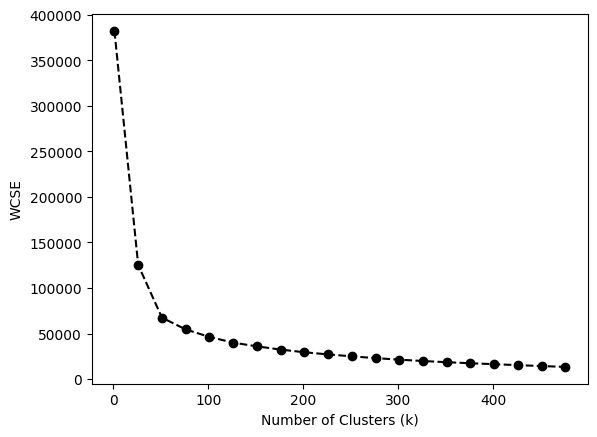

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

random_state = 42
# Elbow Plot Method
k_rng = range(1, 501, 25)
sse = []

# Compute WCSE for all possible total clusters.
for k in k_rng:
  km = KMeans(n_clusters=k, random_state=random_state)
  km.fit(X_reduced_train)
  sse.append(km.inertia_)
  print(f'K value {k} + inertia {km.inertia_}')

# Plot the Elbow Plot
plt.plot(k_rng, sse, linestyle='--', marker='o', color='black')
plt.xlabel("Number of Clusters (k)")
plt.ylabel('WCSE')

plt.plot




From the visual, we notice a significantly sharp decline when the number of clusters k = 51. We use 51 clusters from here on out moving forward.

In [ ]:
# Set up the chosen K Means
km = KMeans(n_clusters=51, random_state=random_state)
km.fit(X_reduced_train)

# Take the clustering centers
A = km.cluster_centers_

# Get the pseudo archetype information
print(f"Pseudo Archetype (A) : {A.shape}")
print(f'Weighted Cluster Sum of Square Errors - {km.inertia_}')


Pseudo Archetype (A) : (51, 37)
Weighted Cluster Sum of Square Errors - 67463.37817413991


#### Sample Random Probability Vectors Test Code

In [ ]:
# Kraemer Algorithm for sampling random probability vectors on the simplex.
# Sum for i=1 to n, p_i >= 0
# Sum of the total probabilities must be equal to 1.

def sample_simplex_uniform(n_samples, n_dim, random_state = None):
  '''
  Sample random probability vectors on the simplex using the Kraemer Algorithm.

  Algorithm Steps:
  1. Select x_1,.....,x_(n-1) from a uniform distribution between 0 to 1.
  2. Sort the x_i in place.
  3. Compute the differences between the consecutive values.

  Args:
      n_samples: Number of probability vectors to generate
      n_dim: Dimension of each probability vector (hidden_size)
      random_state: Random seed for reproducibility

  Returns:
      codes: (n_samples, n_dim) array where each row sums to 1
  '''

  if random_state is not None:
    np.random.seed(random_state)

  # Step 1: Select the n-1 x values uniformly distribution between 0 to 1.
  samples_uniform = np.random.uniform(0, 1, size=(n_samples, n_dim - 1))

  # Achieve boundaries, sort them
  with_boundaries = np.concatenate(
      [np.zeros((n_samples, 1)),
       samples_uniform,
       np.ones((n_samples, 1))]
  , axis=1)

  # Step 2: Sort the x_is in place
  print(with_boundaries)
  sorted_values = np.sort(with_boundaries, axis=1)

  # Step 3: Take the differences between consecutive sorted values
  codes = np.diff(sorted_values, axis=1)
  assert np.allclose(codes.sum(axis=1), 1.0)

  return codes

In [ ]:
# Generate the random codes for the training points.
n_train = X_reduced_train.shape[0]
hidden_size = 51

random_codes = sample_simplex_uniform(
    n_samples=n_train,
    n_dim=hidden_size,
    random_state=45
)

# Print statements to test the sample simplex uniform functionality.
print(f'Random codes shape: {random_codes.shape}')
print(f'Codes sum to 1: {np.allclose(random_codes.sum(axis=1), 1.0)}')
print(f'All non-negative: {(random_codes >= 0).all()}')
print(f'Example code (first point): {random_codes[0, :5]}... (showing first 5)')
print(f'Example code sum: {random_codes[0].sum():.6f}')
print(f'Mean sparsity: {(random_codes > 0.01).sum(axis=1).mean():.2f} active components')

[[0.         0.98901151 0.54954473 ... 0.85586907 0.06693827 1.        ]
 [0.         0.18395199 0.17216682 ... 0.72275521 0.66863599 1.        ]
 [0.         0.5237495  0.29788448 ... 0.15171065 0.62861949 1.        ]
 ...
 [0.         0.51451604 0.33078022 ... 0.82433485 0.2570143  1.        ]
 [0.         0.28053812 0.91654325 ... 0.37240772 0.98353017 1.        ]
 [0.         0.70869856 0.35035733 ... 0.98445411 0.48533577 1.        ]]
Random codes shape: (10000, 51)
Codes sum to 1: True
All non-negative: True
Example code (first point): [0.048522   0.01841627 0.00760251 0.00274878 0.01684936]... (showing first 5)
Example code sum: 1.000000
Mean sparsity: 30.87 active components


#### Compute the Reconstruction to Locality Loss Ratio

In [ ]:
def compute_loss_ratio(X, A, codes, batch_size=1000):
    """
    Compute the ratio of reconstruction loss to locality loss (memory-efficient).

    Args:
        X: (n_samples, input_size) data matrix
        A: (hidden_size, input_size) pseudo-dictionary (archetypes)
        codes: (n_samples, hidden_size) random probability vectors
        batch_size: Process this many samples at a time

    Returns:
        ratio: reconstruction_loss / locality_loss
        recon_loss: reconstruction loss value
        locality_loss: locality loss value
    """
    n_samples = X.shape[0]

    total_recon_loss = 0.0
    total_locality_loss = 0.0

    # Process in batches to save memory
    for start_idx in range(0, n_samples, batch_size):
        end_idx = min(start_idx + batch_size, n_samples)

        X_batch = X[start_idx:end_idx]
        codes_batch = codes[start_idx:end_idx]
        batch_n = X_batch.shape[0]

        # Reconstruction: y_hat = codes @ A
        Y_hat_batch = codes_batch @ A

        # Reconstruction loss for this batch
        recon_batch = 0.5 * np.sum((X_batch - Y_hat_batch) ** 2)
        total_recon_loss += recon_batch

        # Locality loss: sum_j x_ij * ||y_i - a_j||^2
        # Compute using efficient matrix operations
        # distances_sq[i,j] = ||X_batch[i] - A[j]||^2

        # Method: ||a - b||^2 = ||a||^2 + ||b||^2 - 2*a·b
        X_sq = np.sum(X_batch ** 2, axis=1, keepdims=True)  # (batch_n, 1)
        A_sq = np.sum(A ** 2, axis=1, keepdims=True).T      # (1, hidden_size)
        XA = X_batch @ A.T                                    # (batch_n, hidden_size)

        distances_sq = X_sq + A_sq - 2 * XA  # (batch_n, hidden_size)

        # Locality loss for this batch
        locality_batch = np.sum(codes_batch * distances_sq)
        total_locality_loss += locality_batch

        # Optional: Print progress for large datasets
        if (end_idx % 50000) == 0:
            print(f'  Processed {end_idx}/{n_samples} samples...')

    # Average over all samples
    reconstruction_loss = total_recon_loss / n_samples
    locality_loss = total_locality_loss / n_samples

    # Compute ratio
    ratio = reconstruction_loss / locality_loss if locality_loss > 0 else np.inf

    return ratio, reconstruction_loss, locality_loss


# Step 3: Compute loss ratios (memory-efficient)
print("\nStep 3: Computing loss ratios with random codes...")

# You can now use the full training set
ratio, recon, locality = compute_loss_ratio(
    X_reduced_train,
    A,
    random_codes,
    batch_size=2000  # Adjust based on your memory
)

print(f'\nResults on {X_train.shape[0]} samples:')
print(f'Reconstruction loss: {recon:.6f}')
print(f'Locality loss: {locality:.6f}')
print(f'Ratio (recon/locality): {ratio:.6f}')
print(f'\nThis means locality is naturally {1/ratio:.2f}x larger than reconstruction')
print(f'Suggested C value (to balance): {ratio:.6f}')


Step 3: Computing loss ratios with random codes...

Results on 253993 samples:
Reconstruction loss: 23.938346
Locality loss: 239.077381
Ratio (recon/locality): 0.100128

This means locality is naturally 9.99x larger than reconstruction
Suggested C value (to balance): 0.100128


#### PCA Model Implementation


In [ ]:
'''
Steps for regular PCA:
  1) Center Data
  2) Calculate SVD
  3) Select top k PC- encode(projection) to decode(reconstruction)
  5) Calculate Losses, look at how well the data is represented by the top k
     principle components(i.e reconstrcution loss and price prediction loss)
'''
#Regular PCA and Price Prediction:
import torch
import torch.nn as nn
import torch.nn.functional as F

class PCA_Price(nn.Module):
    def __init__(self, n_components, alpha_price=1.0):
        """
        n_components: latent dimension (k)
        alpha_price: weight on supervised price loss
        """
        super().__init__()
        self.n_components = n_components
        self.register_buffer("alpha_price", torch.tensor(alpha_price))

        #PCA componentslearned from data (fit_pca)
        self.register_buffer("W", None)
        self.register_buffer("mean", None)

        #price head
        self.price_head = nn.Linear(n_components, 1)

    def fit_pca(self, X):
        """
        Compute PCA basis from dataset X using SVD
        X: (n_samples, d)
        """
        with torch.no_grad():
            self.mean = X.mean(0, keepdim=True)

            #Step 1: Center data by subtracting mean
            Xc = X - self.mean

            #Step 2: Calculate SVD
            U, S, Vt = torch.linalg.svd(Xc, full_matrices=False)
            self.W = Vt[:self.n_components].T
    #encode: returns centered data
    def encode(self, X):
        """
        X: (batch, d)
        Return latent PCA codes: z = (X - mean) @ W
        """
        Xc = X - self.mean
        return Xc @ self.W

    #decod: returns xhat reconstruction
    def decode(self, z):
        """
        z: (batch, k)
        Return reconstruction: X_hat = z @ W^T + mean
        """
        return z @ self.W.T + self.mean

    def forward(self, X, prices=None):

        z = self.encode(X)
        X_hat = self.decode(z)

        #predict price
        price_hat = self.price_head(z).squeeze(-1)

        #calculate losses
        losses = self.compute_losses(X, X_hat, prices, price_hat)
        return {"z": z, "X_hat": X_hat, "price_hat": price_hat, "losses": losses}

    def compute_losses(self, X, X_hat, prices, price_hat):
        batch = X.shape[0]

        recon_loss = 0.5 * torch.sum((X - X_hat) ** 2) / batch
        total_loss = recon_loss

        price_loss = None
        if prices is not None:
            price_loss = torch.sqrt(F.mse_loss(price_hat, prices))
            total_loss = total_loss + self.alpha_price * price_loss

        return {
            "total": total_loss,
            "reconstruction": recon_loss.item(),
            "price": price_loss.item() if price_loss is not None else None
        }

In [ ]:

'''
Steps for kPCA:
  1) Choose kernal function(here chose RBF kernal)
  2) Compute kernal matrix or all training samples put through kernal function
  3) Center kernal matrix
  4) Eigendecomp of K
  5) Compute kernal embedding and reconstruction loss
'''

#kPCA and Price Prediction:
class KernelPCA_Price(nn.Module):
    def __init__(self, n_components, kernel="rbf", gamma=None, alpha_price=1.0):
        super().__init__()
        self.n_components = n_components
        self.kernel = kernel
        self.gamma = gamma
        self.register_buffer("alpha_price", torch.tensor(alpha_price))

        #get trainign data for kernal evaluations
        self.register_buffer("X_train", None)
        #eigenvectors:
        self.register_buffer("alphas", None)
        #eigenvalues:
        self.register_buffer("lambdas", None)

        #price head
        self.price_head = nn.Linear(n_components, 1)

    def rbf_kernel(self, X, Y):
        gamma = self.gamma or 1.0 / X.shape[1]
        X2 = (X**2).sum(dim=1).view(-1, 1)
        Y2 = (Y**2).sum(dim=1).view(1, -1)
        dist = X2 + Y2 - 2*X@Y.T
        return torch.exp(-gamma * dist)

    def compute_kernel(self, X, Y):
        if self.kernel == "rbf":
            return self.rbf_kernel(X, Y)
        else:
            raise NotImplementedError("Only RBF kernel is implemented")

    def fit(self, X):
        """
        Fit KPCA using training set X
        """
        self.X_train = X.clone()

        #compute kernel matrix
        K = self.compute_kernel(X, X)

        #center K
        n = K.size(0)
        one = torch.ones((n, n), device=K.device)/n
        Kc = K - one@K - K@one + one@K@one

        #Calculate SVD on centered kernel matrix
        eigvals, eigvecs = torch.linalg.eigh(Kc)
        idx = torch.argsort(eigvals, descending=True)
        eigvals = eigvals[idx]
        eigvecs = eigvecs[:, idx]

        #top k components
        self.lambdas = eigvals[:self.n_components]
        self.alphas = eigvecs[:, :self.n_components] / torch.sqrt(self.lambdas)

    #encode: kernel between x and training data then projected
    def encode(self, X):
        K = self.compute_kernel(X, self.X_train)

        #center kernel test matrix to training kernel
        n = self.X_train.shape[0]
        K_train = self.compute_kernel(self.X_train, self.X_train)
        one = torch.ones((n, n), device=K.device)/n
        K_train_c = K_train - one@K_train - K_train@one + one@K_train@one

        Kc = K - K.mean(dim=1, keepdim=True) - K_train.mean(dim=0, keepdim=True) + K_train_c.mean()

        z = Kc @ self.alphas
        return z

    def forward(self, X, prices=None):
        z = self.encode(X)

        #predict price
        price_hat = self.price_head(z).squeeze(-1)

        #calculate losses
        losses = self.compute_losses(prices, price_hat)
        return {"z": z, "price_hat": price_hat, "losses": losses}

    def compute_losses(self, prices, price_hat):
        price_loss = None
        total_loss = 0

        if prices is not None:
            price_loss = torch.sqrt(F.mse_loss(price_hat, prices))
            total_loss = total_loss + self.alpha_price * price_loss

        return {
            "total": total_loss,
            #Note: had to add price = None to avoud errors
            "price": price_loss.item() if price_loss is not None else None
        }


In [ ]:
# Used to obtain better understanding of magnitude of error.(Tarik's code)
def rmse_loss(y_true, y_pred):
  mse_loss = F.mse_loss(y_pred, y_true)
  return torch.sqrt(mse_loss)

In [ ]:
import torch
import torch.nn.functional as F
import time

from google.colab import drive
drive.mount('/content/drive')

save_dir = 'drive/My Drive/MADA_final'


#convert train/val/test sets to torch tensors
X_train_t = torch.tensor(X_reduced_train, dtype=torch.float32)
y_train_t = torch.tensor(y_reduced_train, dtype=torch.float32)

X_val_t = torch.tensor(X_reduced_val, dtype=torch.float32)
y_val_t = torch.tensor(y_reduced_val, dtype=torch.float32)

X_test_t = torch.tensor(X_reduced_test, dtype=torch.float32)
y_test_t = torch.tensor(y_reduced_test, dtype=torch.float32)

#replace NaN values with 0.0 before feeding to PCA/KPCA(havr errors otherwise)
X_train_t = torch.nan_to_num(X_train_t, nan=0.0)
X_val_t = torch.nan_to_num(X_val_t, nan=0.0)
X_test_t = torch.nan_to_num(X_test_t, nan=0.0)

# 1) PCA + Price
n_components = 10
alpha_price = 1.0

pca_model = PCA_Price(n_components=n_components, alpha_price=alpha_price)
pca_model.fit_pca(X_train_t)
optimizer = torch.optim.Adam(pca_model.price_head.parameters(), lr=1e-3)

n_epochs = 200

for epoch in range(n_epochs):

    out = pca_model(X_train_t, y_train_t)
    loss = out["losses"]["total"]

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(f"[PCA] Epoch {epoch}, Total Loss: {loss.item():.4f}, Price RMSE: {out['losses']['price']}")

#Fix! make sure to save PCA model
torch.save(pca_model.state_dict(), f"{save_dir}/pca_model.pt")
print("Saved PCA model to Google Drive at:", f"{save_dir}/pca_model.pt")

torch.save(pca_model.state_dict(), "pca_model.pt")
print("Saved PCA model to pca_model.pt")

#eval
with torch.no_grad():
    out_test = pca_model(X_test_t, y_test_t)
    z_test = out_test["z"]
    X_hat_test = out_test["X_hat"]
    price_hat_test = out_test["price_hat"]

#RMSE
recon_rmse = torch.sqrt(torch.mean((X_test_t - X_hat_test)**2)).item()
print(f"[PCA] Test Price RMSE: {out_test['losses']['price']:.4f}")
print(f"[PCA] Test Reconstruction RMSE: {recon_rmse:.4f}")

# 2) Kernel PCA + Price
kernel = "rbf"
gamma = 0.1

kpca_model = KernelPCA_Price(n_components=n_components, kernel=kernel, gamma=gamma, alpha_price=alpha_price)
kpca_model.fit(X_train_t)
optimizer_kpca = torch.optim.Adam(kpca_model.price_head.parameters(), lr=1e-3)

#set up timer since this takes a while
start_time = time.time()

for epoch in range(n_epochs):
    t0 = time.time()

    out = kpca_model(X_train_t, y_train_t)
    loss = out["losses"]["total"]

    optimizer_kpca.zero_grad()
    loss.backward()
    optimizer_kpca.step()

    epoch_time = time.time() - t0
    avg_time = (time.time() - start_time) / (epoch + 1)
    remaining = avg_time * (n_epochs - (epoch + 1))

    if epoch % 10 == 0:
        print(
            f"[KPCA] Epoch {epoch}/{n_epochs} | "
            f"Loss: {loss.item():.4f} | RMSE: {out['losses']['price']:.4f} | "
            f"Epoch time: {epoch_time:.2f}s | "
            f"ETA: {remaining/60:.1f} min remaining"
        )
torch.save(kpca_model.state_dict(), f"{save_dir}/kpca_model.pt")
print("Saved kPCA model to Google Drive at:", f"{save_dir}/kpca_model.pt")

torch.save(kpca_model.state_dict(), "kpca_model.pt")
print("Saved kPCA model to kpca_model.pt")

#eval
with torch.no_grad():
    out_test_kpca = kpca_model(X_test_t, y_test_t)
    price_hat_kpca = out_test_kpca["price_hat"]

print(f"[KPCA] Test Price RMSE: {out_test_kpca['losses']['price']:.4f}")
print("[KPCA] Reconstruction RMSE: Not implemented (pre-image problem)")

[PCA] Epoch 0, Total Loss: 19.8222, Price RMSE: 8.904871940612793
[PCA] Epoch 10, Total Loss: 19.8083, Price RMSE: 8.890975952148438
[PCA] Epoch 20, Total Loss: 19.7946, Price RMSE: 8.877283096313477
[PCA] Epoch 30, Total Loss: 19.7811, Price RMSE: 8.863812446594238
[PCA] Epoch 40, Total Loss: 19.7679, Price RMSE: 8.85057258605957
[PCA] Epoch 50, Total Loss: 19.7548, Price RMSE: 8.837563514709473
[PCA] Epoch 60, Total Loss: 19.7421, Price RMSE: 8.824782371520996
[PCA] Epoch 70, Total Loss: 19.7295, Price RMSE: 8.81221866607666
[PCA] Epoch 80, Total Loss: 19.7171, Price RMSE: 8.79986572265625
[PCA] Epoch 90, Total Loss: 19.7050, Price RMSE: 8.787713050842285
[PCA] Epoch 100, Total Loss: 19.6930, Price RMSE: 8.775750160217285
[PCA] Epoch 110, Total Loss: 19.6812, Price RMSE: 8.763967514038086
[PCA] Epoch 120, Total Loss: 19.6696, Price RMSE: 8.75235366821289
[PCA] Epoch 130, Total Loss: 19.6582, Price RMSE: 8.740900993347168
[PCA] Epoch 140, Total Loss: 19.6469, Price RMSE: 8.72959709167

In [ ]:
#recreating models
'''
#1)Recreate PCA model
n_components = 10
alpha_price = 1.0

pca_model_recreated = PCA_Price(n_components=n_components, alpha_price=alpha_price)
pca_model_recreated.load_state_dict(torch.load("pca_model.pt"))
pca_model_recreated.eval()

#eval on test set
with torch.no_grad():
    out_test_pca = pca_model_recreated(X_test_t, y_test_t)
    print(f"[PCA] Recreated Model Test Price RMSE: {out_test_pca['losses']['price']:.4f}")
    X_hat_test = out_test_pca["X_hat"]
    recon_rmse = torch.sqrt(torch.mean((X_test_t - X_hat_test)**2)).item()
    print(f"[PCA] Recreated Model Test Reconstruction RMSE: {recon_rmse:.4f}")


# 2)Recreate kPCA model
kernel = "rbf"
gamma = 0.1

kpca_model_recreated = KernelPCA_Price(
    n_components=n_components,
    kernel=kernel,
    gamma=gamma,
    alpha_price=alpha_price
)

kpca_model_recreated.load_state_dict(torch.load("kpca_model.pt"))
kpca_model_recreated.eval()

#eval
with torch.no_grad():
    out_test_kpca = kpca_model_recreated(X_test_t, y_test_t)
    print(f"[KPCA] Recreated Model Test Price RMSE: {out_test_kpca['losses']['price']:.4f}")
    print("[KPCA] Reconstruction RMSE: Not implemented (pre-image problem)")
'''

In [ ]:
def top_features_per_pc(self, feature_names, top_k=10):
    """
    Top pos and neg features for each PC
    """
    pcs = []
    W = self.W.cpu().numpy()
    for i in range(self.n_components):
        comp = W[:, i]
        idx_sorted = comp.argsort()

        pcs.append({
            "component": i,
            "top_positive": [(feature_names[j], comp[j])
                             for j in idx_sorted[-top_k:][::-1]],
            "top_negative": [(feature_names[j], comp[j])
                             for j in idx_sorted[:top_k]]
        })
    return pcs

In [ ]:
#look at the component sparsity
def component_sparsity(self):
    W = self.W.abs()
    l0 = (W == 0).float().mean().item()
    l1 = W.sum(dim=0).cpu().numpy()  # per component
    return {"L0_zero_fraction": l0, "L1_norms": l1}

In [ ]:
#loadins per PC/maybe heatmap later
def plot_pca_component(self, component_idx, feature_names, top_k=15):
    w = self.W[:, component_idx].cpu().numpy()
    idx = np.argsort(np.abs(w))[-top_k:]
    plt.barh([feature_names[i] for i in idx], w[idx])
    plt.title(f"PCA Component {component_idx} – Top {top_k} Features")
    plt.show()

In [ ]:
#Influence scores per feature for kpca
def kpca_feature_influence(self, X_sample):
    X_sample = X_sample.clone().requires_grad_(True)
    z = self.encode(X_sample.unsqueeze(0))
    z.sum().backward()
    return X_sample.grad.abs().detach()

In [ ]:
#sparsity of the eigenvectors and rank of kernal matrix
def kpca_sparsity(self):
    A = self.alphas.abs()
    return {
        "alpha_L0_zero_fraction": (A == 0).float().mean().item(),
        "alpha_L1_norms": A.sum(dim=0).cpu().numpy()
    }

In [ ]:
#just summarize findings in pretty text
def summarize_pca(self):
    return {
        "reconstruction_rmse": ...,
        "price_rmse": ...,
        "component_sparsity": self.component_sparsity(),
        "variance_explained": (self.W**2).sum(0).cpu().numpy()
    }

In [ ]:
#calling all functuons
pca_model.top_features_per_pc(feature_names, top_k=10)
pcs = pca_model.top_features_per_pc(feature_names, top_k=10)
for pc in pcs:
    print(pc)

pca_model.component_sparsity()
sparsity = pca_model.component_sparsity()
print(sparsity)

pca_model.plot_pca_component(component_idx=0, feature_names=feature_names, top_k=15)


sample = X_test_t[0]
influences = kpca_model.kpca_feature_influence(sample)
print(influences)

kpca_model.kpca_sparsity()
print(kpca_model.kpca_sparsity())


summary = pca_model.summarize_pca()
print(summary)